# Analisa Algoritma

In [2]:
# Path to result 
result_path = "../data/result"

In [3]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import os

# supress warnings
warnings.filterwarnings("ignore")


csv_file = os.path.join(result_path, "Allbenchmark.csv")
df = pd.read_csv(csv_file)

display(df.tail())
df.info()

,id_test_case,algoritma,resolusi,kategori_jarak,start_hex,goal_hex,hops,jarak_meter,referensi_meter,waktu_microsec,nodes_expanded,nodes_generated,status,path_hex_ids
3145,150,UCS,11,long,8b8d8eb48a14fff,8b8d8c78949afff,394,19437.9075,16288.67,48096,121258,121775,Success,[paths/res11/tc150_UCS.csv]
3146,150,GBFS,11,long,8b8d8eb48a14fff,8b8d8c78949afff,449,22003.1059,16288.67,1577,1849,2676,Success,[paths/res11/tc150_GBFS.csv]
3147,150,A*,11,long,8b8d8eb48a14fff,8b8d8c78949afff,394,19437.8230,16288.67,30412,44188,45691,Success,[paths/res11/tc150_A*.csv]
3148,150,Theta*,11,long,8b8d8eb48a14fff,8b8d8c78949afff,2,17357.0952,16288.67,3738962,21573,26596,Success,[paths/res11/tc150_Theta*.csv]
3149,150,BFS,11,long,8b8d8eb48a14fff,8b8d8c78949afff,394,19438.0006,16288.67,7629,121258,121754,Success,[paths/res11/tc150_BFS.csv]


<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_test_case     3150 non-null   int64  
 1   algoritma        3150 non-null   str    
 2   resolusi         3150 non-null   int64  
 3   kategori_jarak   3150 non-null   str    
 4   start_hex        3150 non-null   str    
 5   goal_hex         3150 non-null   str    
 6   hops             3150 non-null   int64  
 7   jarak_meter      3150 non-null   float64
 8   referensi_meter  3150 non-null   float64
 9   waktu_microsec   3150 non-null   int64  
 10  nodes_expanded   3150 non-null   int64  
 11  nodes_generated  3150 non-null   int64  
 12  status           3150 non-null   str    
 13  path_hex_ids     3150 non-null   str    
dtypes: float64(2), int64(6), str(6)
memory usage: 344.7 KB


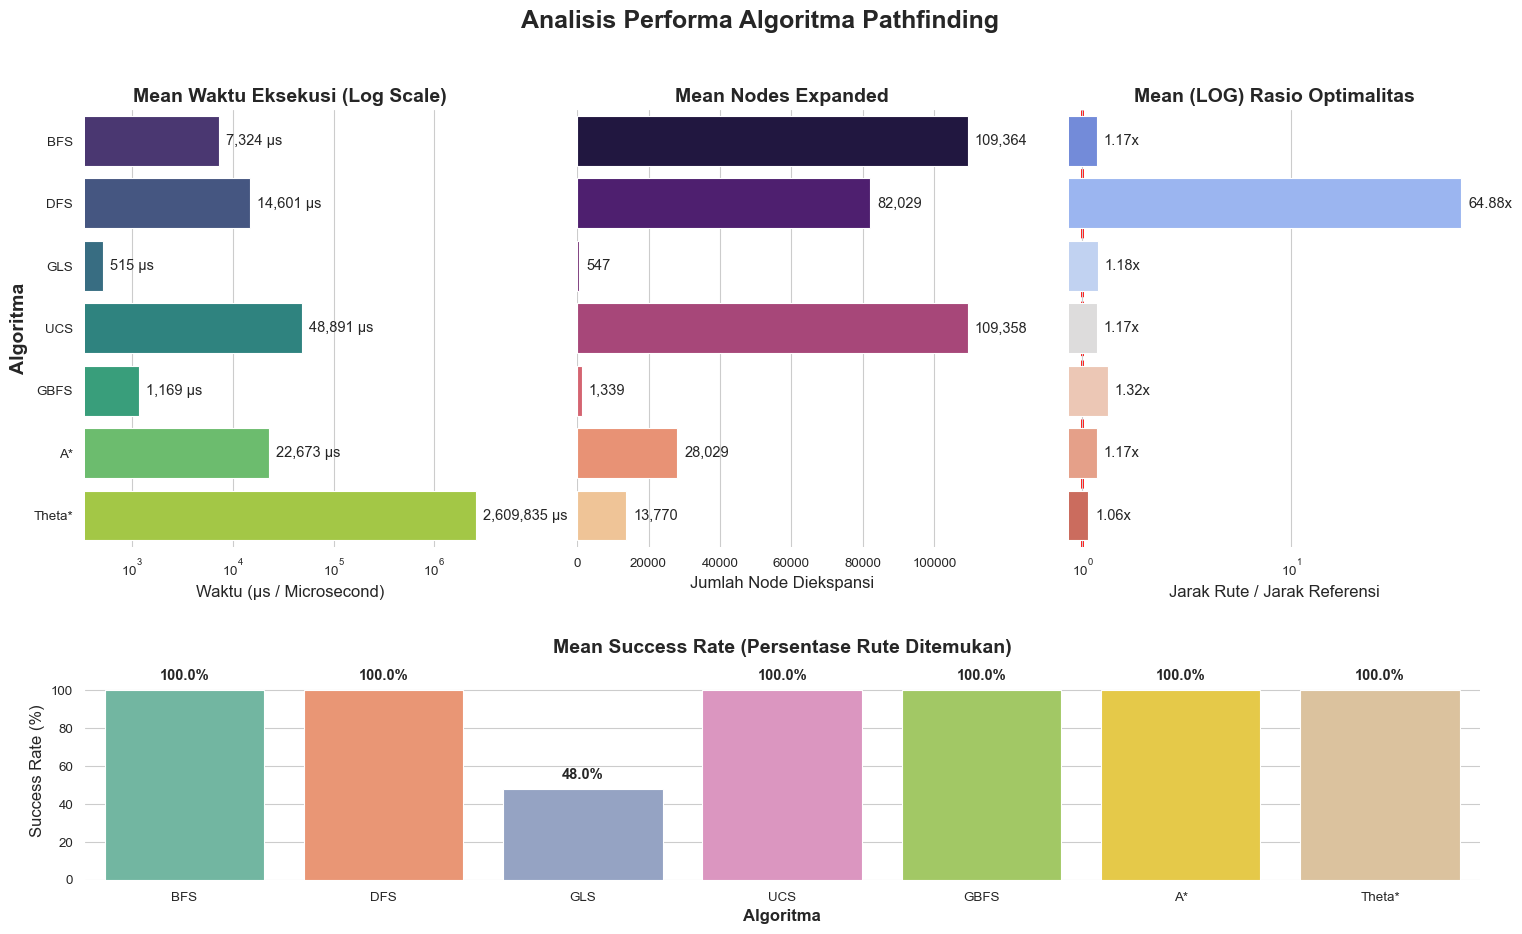

In [5]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

filtered_df = df[(df['resolusi'] == 11) & (df['kategori_jarak'] == 'long')].copy()

filtered_df['rasio_optimalitas'] = filtered_df['jarak_meter'] / filtered_df['referensi_meter']
filtered_df['is_success'] = filtered_df['status'].astype(str).str.lower().isin(['success', 'sukses', 'true']) * 100.0

algo_order = ['BFS', 'DFS', 'GLS', 'UCS', 'GBFS', 'A*', 'Theta*']

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[2, 1], hspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)
ax3 = fig.add_subplot(gs[1, :])

fig.suptitle('Analisis Performa Algoritma Pathfinding', 
             fontsize=18, fontweight='bold', y=0.98)

sns.barplot(
    x='waktu_microsec', y='algoritma', data=filtered_df, estimator=np.mean, 
    errorbar=None, order=algo_order, palette='viridis', ax=ax0, orient='h'
)
ax0.set_xscale('log')
ax0.set_title('Mean Waktu Eksekusi (Log Scale)', fontsize=14, fontweight='bold')
ax0.set_xlabel('Waktu (µs / Microsecond)', fontsize=12)
ax0.set_ylabel('Algoritma', fontsize=14, fontweight='bold')

for p in ax0.patches:
    width = p.get_width()
    if width > 0:
        ax0.annotate(f'{width:,.0f} µs', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points')

sns.barplot(
    x='nodes_expanded', y='algoritma', data=filtered_df, estimator=np.mean, 
    errorbar=None, order=algo_order, palette='magma', ax=ax1, orient='h'
)
ax1.set_title('Mean Nodes Expanded', fontsize=14, fontweight='bold')
ax1.set_xlabel('Jumlah Node Diekspansi', fontsize=12)
ax1.set_ylabel('')
plt.setp(ax1.get_yticklabels(), visible=False)

for p in ax1.patches:
    width = p.get_width()
    if width > 0:
        ax1.annotate(f'{int(width):,}', (width, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points')

sns.barplot(
    x='rasio_optimalitas', y='algoritma', data=filtered_df, estimator=np.mean, 
    errorbar=None, order=algo_order, palette='coolwarm', ax=ax2, orient='h'
)
ax2.set_xscale('log')
ax2.set_title('Mean (LOG) Rasio Optimalitas', fontsize=14, fontweight='bold')
ax2.set_xlabel('Jarak Rute / Jarak Referensi', fontsize=12)
ax2.set_ylabel('')
plt.setp(ax2.get_yticklabels(), visible=False)

ax2.axvline(1.0, color='red', linestyle='--', linewidth=2, zorder=0)

for p in ax2.patches:
    width = p.get_width()
    if width > 0:
        ax2.annotate(f'{width:,.2f}x', (width, p.get_y() + p.get_height() / 2.), ha='left', va='center', xytext=(5, 0), textcoords='offset points')

sns.barplot(
    x='algoritma', y='is_success', data=filtered_df, estimator=np.mean, 
    errorbar=None, order=algo_order, palette='Set2', ax=ax3
)
ax3.set_title('Mean Success Rate (Persentase Rute Ditemukan)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Algoritma', fontsize=12, fontweight='bold')
ax3.set_ylabel('Success Rate (%)', fontsize=12)
ax3.set_ylim(0, 115)

for p in ax3.patches:
    height = p.get_height()
    ax3.annotate(f'{height:,.1f}%', (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                 fontweight='bold')

sns.despine(left=True, bottom=True)
output_file = os.path.join(result_path, "analisis_performa_algoritma.png")
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()